In [4]:
# Parameters and scaling factors
# Nominal values are taken from UN_model/reports/UNmodel.md, section "Parametri UN da Rizk".
# Edit this cell first, then Run All.

# Run controls
MODEL_LABEL = 'M7_Rizk_nominal_original_Dv'
DT_H = 0.5
N_MODES = 40
TEMPERATURE_GRID_K = list(range(900, 2001, 100))
BURNUPS_FIMA = [1.1, 1.3, 3.2]
HISTORY_POINT = {'T': 1600.0, 'burnup': 1.3}

# Model switches
USE_PHI_GAS_RESOLUTION = False
USE_NUCLEATION_MASS_COUPLING = False
USE_BULK_DISLOCATION_CAPTURE = True
USE_DISLOCATION_COALESCENCE = True

# Irradiation condition used for Rizk/DN1 validation in UNmodel.md
fission_rate = 5.0e19
scaling_fission_rate = 1.0

# Gas yield used by the M7 UN implementation
xe_yield = 0.24
scaling_xe_yield = 1.0

# Xe gas diffusivity: Dg = D1 + D2 + D3
D10_Xe = 1.56e-3
scaling_D10_Xe = 1.0
Q1_Xe = 4.94
scaling_Q1_Xe = 1.0
A20_Xe = 1.21e-67
scaling_A20_Xe = 1.0
B21_Xe = 25.87
scaling_B21_Xe = 1.0
B22_Xe = -1.49
scaling_B22_Xe = 1.0
B23_Xe = 0.0
scaling_B23_Xe = 1.0
A30_Xe = 1.85e-39
scaling_A30_Xe = 1.0
scaling_Dg_D1 = 1.0
scaling_Dg_D3 = 1.0
scaling_Dg_total = 1.0

# Uranium vacancy diffusivity: Dv = D1 + D2
D10_vU = 1.35e-2
scaling_D10_vU = 1.0
Q1_vU = 5.66
scaling_Q1_vU = 1.0
# Original Rizk Table 2 value. Do not replace with the previous Fig. 4 fit value.
A20_vU = 1.32e-19
scaling_A20_vU = 1.0
B21_vU = -0.62
scaling_B21_vU = 1.0
B22_vU = -0.04
scaling_B22_vU = 1.0
scaling_Dv_D1 = 1.0
scaling_Dv_D2 = 1.0
scaling_Dv_total = 1.0

# Re-solution b = b0(R) * fission_rate
scaling_b_total = 1.0
scaling_b_bulk = 1.0
scaling_b_dislocation = 1.0

# Trapping rates gb and gd
scaling_gb = 1.0
scaling_gd_total = 1.0
scaling_gd_bubble = 1.0
scaling_gd_line = 1.0
gd_line_alpha = 1.0
scaling_gd_line_alpha = 1.0

# Nucleation and matrix parameters
Omega_fg = 8.5e-29
scaling_Omega_fg = 1.0
f_n = 1.0e-6
scaling_f_n = 1.0
lattice_parameter = 4.889e-10
scaling_lattice_parameter = 1.0
Omega_matrix = lattice_parameter**3 / 4.0
scaling_Omega_matrix = 1.0
gamma = 1.11
scaling_gamma = 1.0

# Grain-boundary parameters from Rizk table, kept here for visibility.
Dv_gb_multiplier = 1.0e6
scaling_Dv_gb_multiplier = 1.0
delta_gb = 4.0e-10
scaling_delta_gb = 1.0
N_gf0 = 2.0e13
scaling_N_gf0 = 1.0
theta_deg = 59.0
scaling_theta_deg = 1.0
R_gf = 2.42e-10
scaling_R_gf = 1.0
F_c_sat = 0.5
scaling_F_c_sat = 1.0

# Grain and dislocation parameters
r_grain = 6.0e-6
scaling_r_grain = 1.0
K_d = 5.0e5
scaling_K_d = 1.0
r_d = 3.46e-10
scaling_r_d = 1.0
rho_d = 3.0e13
scaling_rho_d = 1.0
Z_d = 5.0
scaling_Z_d = 1.0

# Constants
kB_eV = 8.617333262e-5
scaling_kB_eV = 1.0

# M7 structural factors
scaling_coalescence_d = 1.0 if USE_DISLOCATION_COALESCENCE else 0.0
scaling_capture = 1.0 if USE_BULK_DISLOCATION_CAPTURE else 0.0


In [5]:
from pathlib import Path
import importlib.util
import sys
import math

import matplotlib.pyplot as plt

HERE = Path.cwd()
for parent in [HERE, *HERE.parents]:
    candidate = parent / 'UN_model' / 'optuna' / 'M7_v14' / 'UN_M7_optuna_calibration_v14_rhoSat_qgbStrict_NdAnchors_STANDALONE.py'
    if candidate.exists():
        MODEL_FILE = candidate
        REPO_ROOT = parent
        break
else:
    raise FileNotFoundError('Could not find the M7 v14 standalone solver file from this notebook location.')

spec = importlib.util.spec_from_file_location('m7_solver', MODEL_FILE)
m7 = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = m7
spec.loader.exec_module(m7)

m7.USE_PHI_GAS_RESOLUTION = USE_PHI_GAS_RESOLUTION
m7.USE_NUCLEATION_MASS_COUPLING = USE_NUCLEATION_MASS_COUPLING
m7.USE_BULK_DISLOCATION_CAPTURE = USE_BULK_DISLOCATION_CAPTURE
m7.MODEL_FAMILY = 'capture_only'

PLOTS_DIR = REPO_ROOT / 'UN_model' / 'notebooks' / 'M7_rizk_nominal_manual_runner_plots'
PLOTS_DIR.mkdir(exist_ok=True)

print(f'Solver file: {MODEL_FILE}')
print(f'Plot folder: {PLOTS_DIR}')
print(f'Original Rizk A20_vU used here: {A20_vU:.3e}')
print(f'M7 standalone default A20_vU fit value: {m7.UNParameters().A20_vU_fig4_refit:.3e}')


Solver file: /home/destro/sciantix-official/UN_model/optuna/M7_v14/UN_M7_optuna_calibration_v14_rhoSat_qgbStrict_NdAnchors_STANDALONE.py
Plot folder: /home/destro/sciantix-official/UN_model/notebooks/M7_rizk_nominal_manual_runner_plots
Original Rizk A20_vU used here: 1.320e-19
M7 standalone default A20_vU fit value: 4.630e-29


In [6]:
def make_parameters(T, burnup, keep_history=False):
    return m7.UNParameters(
        temperature=float(T),
        fission_rate=fission_rate * scaling_fission_rate,
        grain_radius=r_grain * scaling_r_grain,
        target_burnup_percent_fima=float(burnup),
        dt=DT_H * 3600.0,
        n_modes=N_MODES,
        xe_yield=xe_yield * scaling_xe_yield,
        D10=D10_Xe * scaling_D10_Xe,
        Q1=Q1_Xe * scaling_Q1_Xe,
        A20_xe=A20_Xe * scaling_A20_Xe,
        B21_xe=B21_Xe * scaling_B21_Xe,
        B22_xe=B22_Xe * scaling_B22_Xe,
        B23_xe=B23_Xe * scaling_B23_Xe,
        A30=A30_Xe * scaling_A30_Xe,
        Dg_D1_scale=scaling_Dg_D1,
        Dg_D3_scale=scaling_Dg_D3,
        Dg_scale=scaling_Dg_total,
        D10_vU=D10_vU * scaling_D10_vU,
        Q1_vU=Q1_vU * scaling_Q1_vU,
        A20_vU_fig4_refit=A20_vU * scaling_A20_vU,
        B21_vU_refit=B21_vU * scaling_B21_vU,
        B22_vU_refit=B22_vU * scaling_B22_vU,
        Dv_D1_scale=scaling_Dv_D1,
        Dv_D2_scale=scaling_Dv_D2,
        Dv_scale=scaling_Dv_total,
        b_scale=scaling_b_total,
        b_bulk_scale=scaling_b_bulk,
        b_dislocation_scale=scaling_b_dislocation,
        gb_scale=scaling_gb,
        gd_scale=scaling_gd_total,
        gd_bubble_scale=scaling_gd_bubble,
        gd_line_scale=scaling_gd_line,
        gd_line_alpha=gd_line_alpha * scaling_gd_line_alpha,
        omega_fg=Omega_fg * scaling_Omega_fg,
        lattice_parameter=lattice_parameter * scaling_lattice_parameter,
        gamma_b=gamma * scaling_gamma,
        f_n=f_n * scaling_f_n,
        K_d=K_d * scaling_K_d,
        r_d=r_d * scaling_r_d,
        rho_d=rho_d * scaling_rho_d,
        Z_d=Z_d * scaling_Z_d,
        kB_eV=kB_eV * scaling_kB_eV,
        coalescence_d_scale=scaling_coalescence_d,
        capture_scale=scaling_capture,
        bulk_seed_radius_nm=0.0,
    )


def run_model_point_manual(T, burnup, keep_history=False):
    p = make_parameters(T, burnup, keep_history=keep_history)
    hist, rates = m7.solve_UN_M7(p, keep_history=keep_history)
    pb_eq = hist['p_b_eq'][-1]
    pd_eq = hist['p_d_eq'][-1]
    return {
        'T': float(T),
        'burnup': float(burnup),
        'swelling_b_percent': 100.0 * hist['swelling_b'][-1],
        'swelling_d_percent': 100.0 * hist['swelling_d'][-1],
        'swelling_ig_percent': 100.0 * hist['swelling_ig'][-1],
        'Nb': hist['Nb'][-1],
        'Nd': hist['Nd'][-1],
        'Rb_nm': hist['Rb'][-1] * 1.0e9,
        'Rd_nm': hist['Rd'][-1] * 1.0e9,
        'p_b_over_eq': hist['p_b'][-1] / pb_eq if pb_eq > 0.0 else math.nan,
        'p_d_over_eq': hist['p_d'][-1] / pd_eq if pd_eq > 0.0 else math.nan,
        'matrix_gas_percent': hist['matrix_gas_percent'][-1],
        'bulk_gas_percent': hist['bulk_gas_percent'][-1],
        'dislocation_gas_percent': hist['dislocation_gas_percent'][-1],
        'qgb_gas_percent': hist['qgb_gas_percent'][-1],
        'rates': rates,
        'hist': hist if keep_history else None,
    }


def experimental_swelling_points(burnup):
    return [p for p in m7.EXP_SWELLING_T if abs(float(p['burnup']) - float(burnup)) < 1.0e-9]


In [7]:
sweeps = {}
for bu in BURNUPS_FIMA:
    sweeps[bu] = [run_model_point_manual(T, bu, keep_history=False) for T in TEMPERATURE_GRID_K]

history = run_model_point_manual(HISTORY_POINT['T'], HISTORY_POINT['burnup'], keep_history=True)
print({bu: len(rows) for bu, rows in sweeps.items()})
print('History point:', HISTORY_POINT)
print('Dv at history point:', history['rates']['Dv'])
print('Dv1:', history['rates']['Dv1'])
print('Dv2 with original Rizk A20_vU:', history['rates']['Dv2'])


{1.1: 12, 1.3: 12, 3.2: 12}
History point: {'T': 1600.0, 'burnup': 1.3}
Dv at history point: 1.2686134480160945e-12
Dv1: 2.005018746656425e-20
Dv2 with original Rizk A20_vU: 1.2686134279659071e-12


saved /home/destro/sciantix-official/UN_model/notebooks/M7_rizk_nominal_manual_runner_plots/swelling_vs_temperature.png


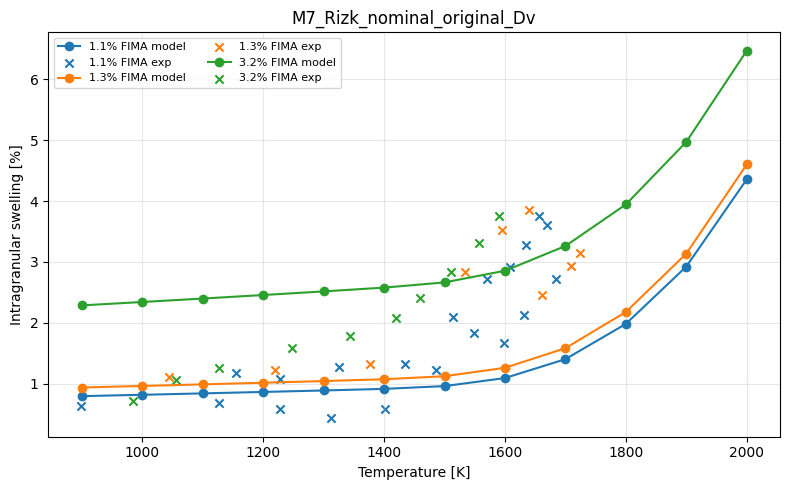

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for bu, rows in sweeps.items():
    ax.plot([r['T'] for r in rows], [r['swelling_ig_percent'] for r in rows], marker='o', label=f'{bu}% FIMA model')
    pts = experimental_swelling_points(bu)
    if pts:
        ax.scatter([p['T'] for p in pts], [p['swelling'] for p in pts], s=35, marker='x', label=f'{bu}% FIMA exp')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Intragranular swelling [%]')
ax.set_title(MODEL_LABEL)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
out = PLOTS_DIR / 'swelling_vs_temperature.png'
fig.savefig(out, dpi=180)
print('saved', out)
plt.show()


saved /home/destro/sciantix-official/UN_model/notebooks/M7_rizk_nominal_manual_runner_plots/radius_density_1p3FIMA.png


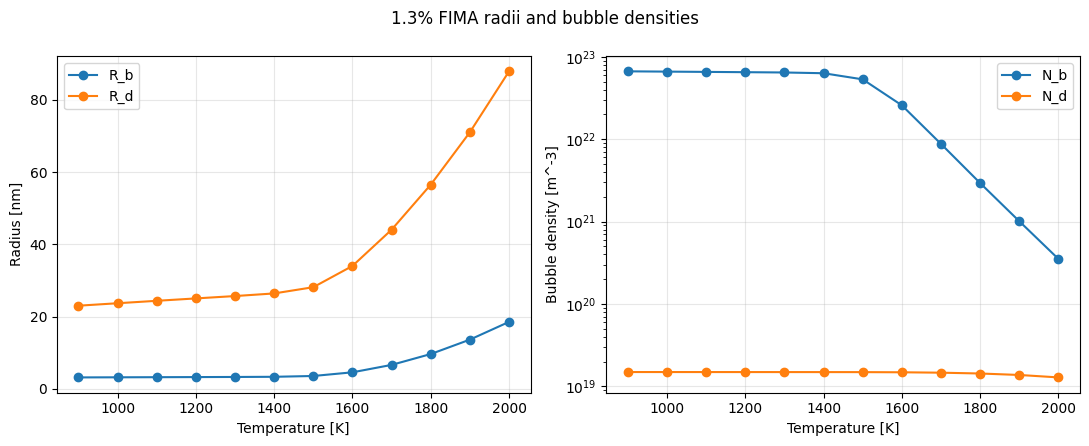

In [9]:
rows = sweeps[1.3]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot([r['T'] for r in rows], [r['Rb_nm'] for r in rows], marker='o', label='R_b')
axes[0].plot([r['T'] for r in rows], [r['Rd_nm'] for r in rows], marker='o', label='R_d')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Radius [nm]')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].semilogy([r['T'] for r in rows], [r['Nb'] for r in rows], marker='o', label='N_b')
axes[1].semilogy([r['T'] for r in rows], [r['Nd'] for r in rows], marker='o', label='N_d')
axes[1].set_xlabel('Temperature [K]')
axes[1].set_ylabel('Bubble density [m^-3]')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.suptitle('1.3% FIMA radii and bubble densities')
fig.tight_layout()
out = PLOTS_DIR / 'radius_density_1p3FIMA.png'
fig.savefig(out, dpi=180)
print('saved', out)
plt.show()


saved /home/destro/sciantix-official/UN_model/notebooks/M7_rizk_nominal_manual_runner_plots/gas_partition_1p3FIMA.png


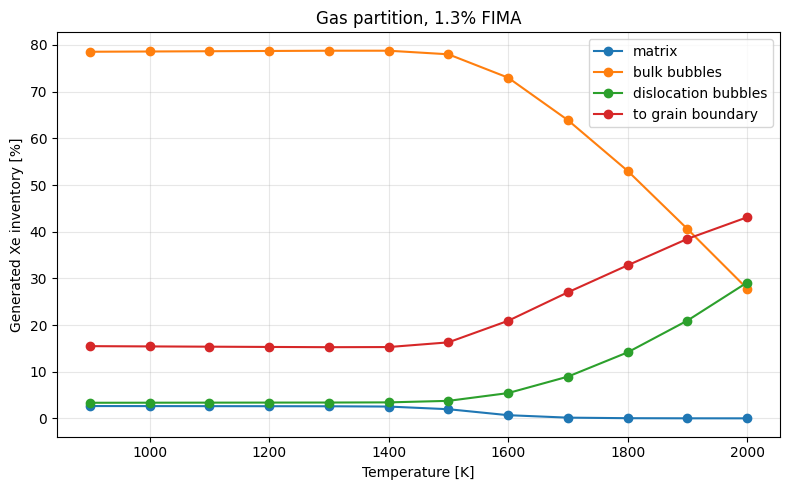

In [10]:
rows = sweeps[1.3]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['T'] for r in rows], [r['matrix_gas_percent'] for r in rows], marker='o', label='matrix')
ax.plot([r['T'] for r in rows], [r['bulk_gas_percent'] for r in rows], marker='o', label='bulk bubbles')
ax.plot([r['T'] for r in rows], [r['dislocation_gas_percent'] for r in rows], marker='o', label='dislocation bubbles')
ax.plot([r['T'] for r in rows], [r['qgb_gas_percent'] for r in rows], marker='o', label='to grain boundary')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Generated Xe inventory [%]')
ax.set_title('Gas partition, 1.3% FIMA')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out = PLOTS_DIR / 'gas_partition_1p3FIMA.png'
fig.savefig(out, dpi=180)
print('saved', out)
plt.show()


saved /home/destro/sciantix-official/UN_model/notebooks/M7_rizk_nominal_manual_runner_plots/history_point.png


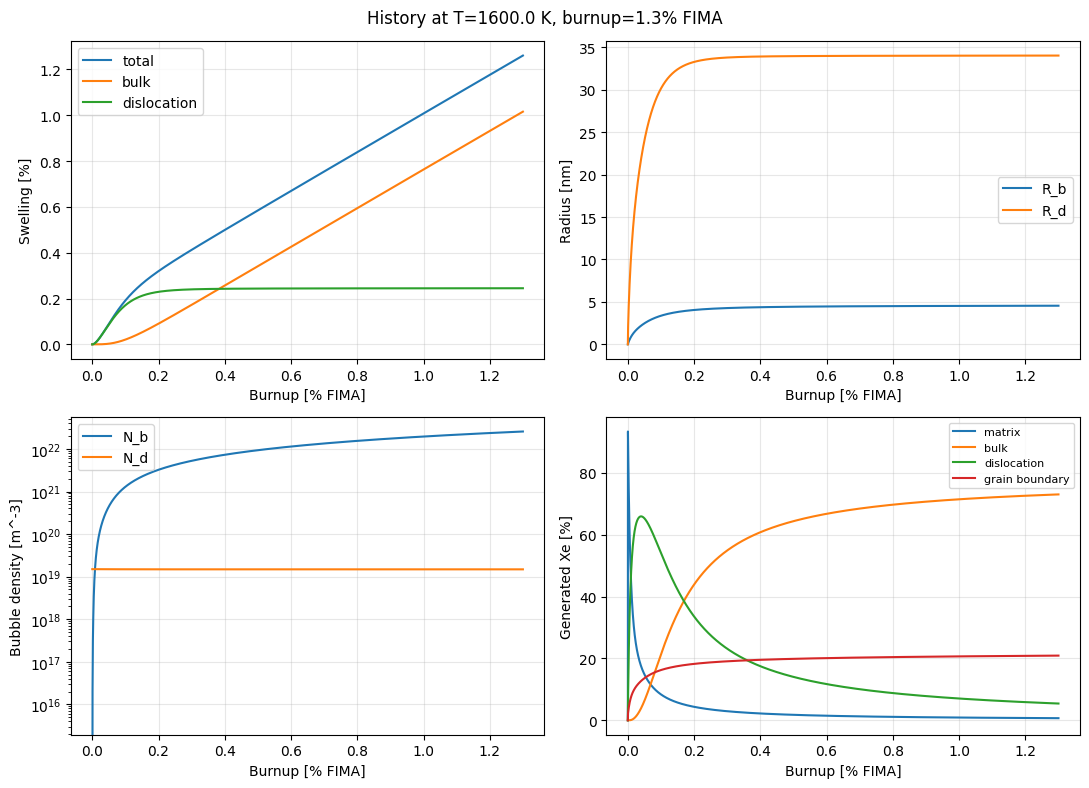

In [11]:
hist = history['hist']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(hist['burnup_percent_fima'], [100.0*x for x in hist['swelling_ig']], label='total')
axes[0, 0].plot(hist['burnup_percent_fima'], [100.0*x for x in hist['swelling_b']], label='bulk')
axes[0, 0].plot(hist['burnup_percent_fima'], [100.0*x for x in hist['swelling_d']], label='dislocation')
axes[0, 0].set_ylabel('Swelling [%]')
axes[0, 0].legend()
axes[0, 1].plot(hist['burnup_percent_fima'], [1e9*x for x in hist['Rb']], label='R_b')
axes[0, 1].plot(hist['burnup_percent_fima'], [1e9*x for x in hist['Rd']], label='R_d')
axes[0, 1].set_ylabel('Radius [nm]')
axes[0, 1].legend()
axes[1, 0].semilogy(hist['burnup_percent_fima'], hist['Nb'], label='N_b')
axes[1, 0].semilogy(hist['burnup_percent_fima'], hist['Nd'], label='N_d')
axes[1, 0].set_ylabel('Bubble density [m^-3]')
axes[1, 0].legend()
axes[1, 1].plot(hist['burnup_percent_fima'], hist['matrix_gas_percent'], label='matrix')
axes[1, 1].plot(hist['burnup_percent_fima'], hist['bulk_gas_percent'], label='bulk')
axes[1, 1].plot(hist['burnup_percent_fima'], hist['dislocation_gas_percent'], label='dislocation')
axes[1, 1].plot(hist['burnup_percent_fima'], hist['qgb_gas_percent'], label='grain boundary')
axes[1, 1].set_ylabel('Generated Xe [%]')
axes[1, 1].legend(fontsize=8)
for ax in axes.ravel():
    ax.set_xlabel('Burnup [% FIMA]')
    ax.grid(True, alpha=0.3)
fig.suptitle(f"History at T={HISTORY_POINT['T']} K, burnup={HISTORY_POINT['burnup']}% FIMA")
fig.tight_layout()
out = PLOTS_DIR / 'history_point.png'
fig.savefig(out, dpi=180)
print('saved', out)
plt.show()
